# 01 - Data Exploration

**Goal**: Understand the dataset, audio fundamentals, and Whisper encoder before building the pipeline.

**Maps to**: Original notebook cells 4-21

**What we do here**:
1. Install/verify dependencies
2. Load the `speechbrain/LargeScaleASR` dataset in streaming mode
3. Inspect sample structure and visualize audio waveforms
4. Understand Whisper encoder and its output dimensions

**Where to run**: Google Colab (free tier works), lab server, or local machine (CPU-only is fine for this notebook).

## 1. Environment Setup

In [1]:
# Uncomment if running on Google Colab
# Pin transformers to the SAME version we use on lab server (4.56.0.dev0)
# This ensures Colab behavior matches production — no surprises later.
!pip install -q git+https://github.com/huggingface/transformers.git@0f9c9088d0260565cd89af2925836ea2f8bfe5f3
!pip install -q datasets librosa matplotlib soundfile

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 9.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 40.5 MB/s eta 0:00:0000:0100:01


In [2]:
import torch
import torchaudio
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
from io import BytesIO
from datasets import load_dataset
from IPython.display import Audio, display

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"torchaudio: {torchaudio.__version__}")
print(f"librosa: {librosa.__version__}")

PyTorch: 2.9.0+cpu
CUDA available: False
torchaudio: 2.9.0+cpu
librosa: 0.11.0


## 2. Load Dataset (Streaming Mode)

We use [speechbrain/LargeScaleASR](https://huggingface.co/datasets/speechbrain/LargeScaleASR) (also known as LoquaciousSet) — 25,000 hours of diverse, transcribed English speech.

Loading in **streaming mode** avoids downloading the full dataset. The dataset has four configs:

| Config | Hours | Samples | Use case |
|--------|-------|---------|----------|
| `small` | 250 | ~123k | Prototyping |
| `medium` | 2,500 | ~1.09M | Mid-scale experiments |
| `large` | 25,000 | ~9.5M | Full training |
| `clean` | 13,000 | ~3.92M | Clean audio only |

**Audio format**: The `wav` field contains raw bytes that are decoded by `soundfile` or `torchaudio`.

In [3]:
# Load dataset in streaming mode — no full download needed
# Using the original notebook's data_files approach for compatibility
ds_stream = load_dataset(
    "speechbrain/LargeScaleASR",
    data_files="small/train-00000*",
    streaming=True,
    split="train"
)

# Grab one sample and inspect its structure
sample = next(iter(ds_stream))
print("Sample keys:", list(sample.keys()))
for key, value in sample.items():
    if key == "wav":
        print(f"  {key}: type={type(value)}, sub-keys={list(value.keys()) if isinstance(value, dict) else 'N/A'}")
    elif key == "text":
        print(f"  {key}: '{value[:80]}...'" if len(str(value)) > 80 else f"  {key}: '{value}'")
    else:
        print(f"  {key}: {value}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Sample keys: ['ID', 'duration', 'wav', 'spk_id', 'sex', 'text']
  ID: 20091124-0900-PLENARY-18-en_20091124-22:35:55_9
  duration: 17.1200008392334
  wav: type=<class 'dict'>, sub-keys=['bytes', 'path']
  spk_id: 1309
  sex: male
  text: 'AND WHAT ABOUT INTEROPERABILITY IN THE RAIL SECTOR ARE NATIONAL BARRIERS PREVENT...'


In [4]:
# Helper: decode audio bytes from the dataset's wav field
def decode_audio(sample):
    """Decode audio bytes from the dataset into a numpy array and sampling rate.
    
    The dataset stores audio as raw bytes in sample['wav']['bytes'].
    We use soundfile to decode them.
    """
    wav_bytes = sample["wav"]["bytes"]
    audio_array, sr = sf.read(BytesIO(wav_bytes))
    # Ensure float32 and mono
    audio_array = audio_array.astype(np.float32)
    if audio_array.ndim > 1:
        audio_array = audio_array.mean(axis=1)  # stereo to mono
    return audio_array, sr

# Decode the first sample
audio_array, sr = decode_audio(sample)
duration = len(audio_array) / sr

print(f"Transcription: {sample['text']}")
print(f"Sampling rate: {sr} Hz")
print(f"Audio shape: {audio_array.shape}")
print(f"Duration: {duration:.2f} seconds")
print(f"Dtype: {audio_array.dtype}")

Transcription: AND WHAT ABOUT INTEROPERABILITY IN THE RAIL SECTOR ARE NATIONAL BARRIERS PREVENTING PROGRESS IN THIS AREA AS WELL OR IS THERE AN UNWILLINGNESS ON THE PART OF THE RAIL INDUSTRY TO EMBRACE THE CONCEPT OF INTEROPERABILITY
Sampling rate: 16000 Hz
Audio shape: (273920,)
Duration: 17.12 seconds
Dtype: float32


## 3. Visualize Audio

Let's visualize the waveform and mel spectrogram using librosa.

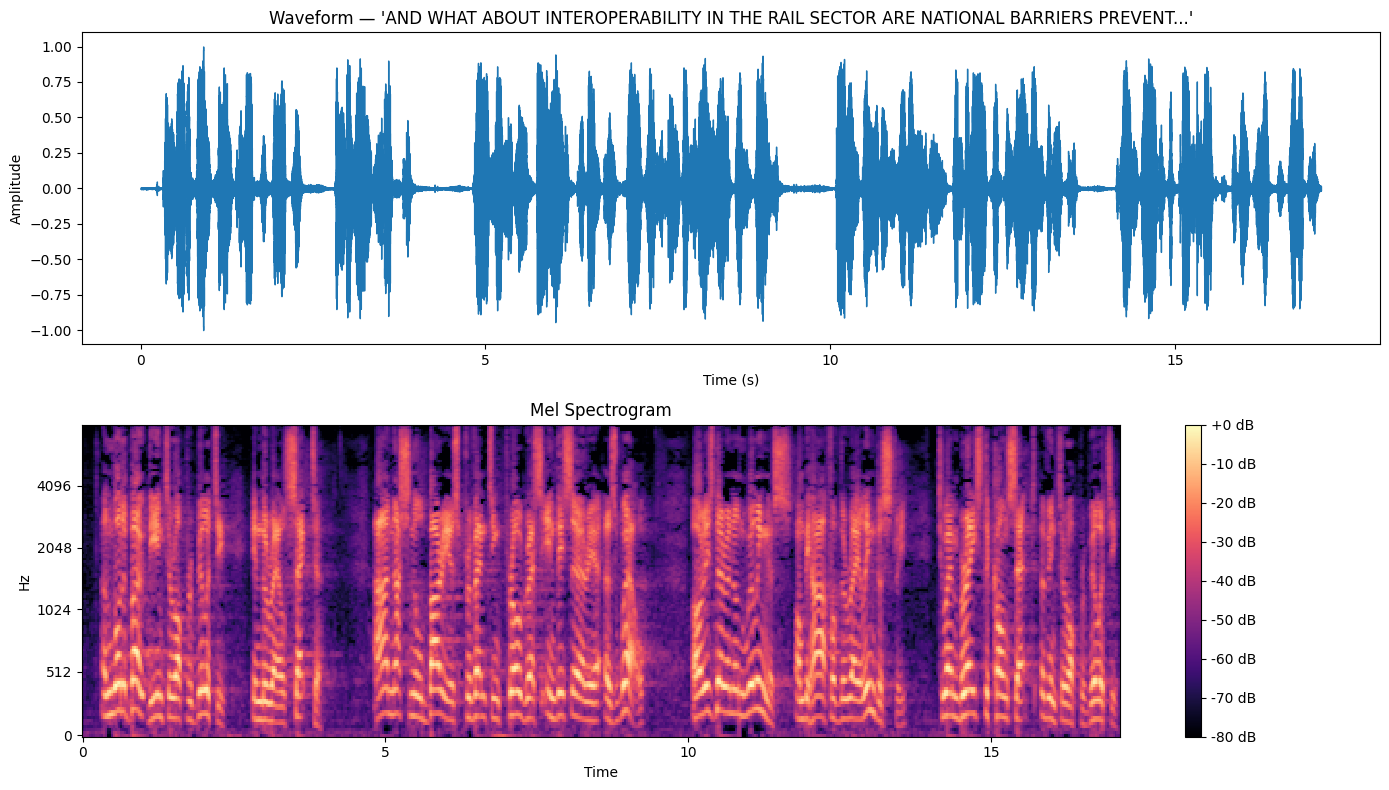

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Waveform
librosa.display.waveshow(audio_array, sr=sr, ax=axes[0])
title_text = sample['text'][:80] + '...' if len(sample['text']) > 80 else sample['text']
axes[0].set_title(f"Waveform — '{title_text}'")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")

# Mel spectrogram
mel_spec = librosa.feature.melspectrogram(y=audio_array, sr=sr, n_mels=128)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
img = librosa.display.specshow(mel_spec_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[1])
axes[1].set_title("Mel Spectrogram")
fig.colorbar(img, ax=axes[1], format="%+2.0f dB")

plt.tight_layout()
plt.show()

In [6]:
# Play the audio in the notebook
display(Audio(audio_array, rate=sr))

## 4. Explore Multiple Samples

Let's look at a few more samples to understand data distribution (durations, text lengths).

In [7]:
# Grab 10 samples to understand the data
samples = list(ds_stream.take(10))

print(f"{'#':<4} {'Duration (s)':<14} {'SR (Hz)':<10} {'Text Len':<10} {'Text Preview'}")
print("-" * 90)
for i, s in enumerate(samples):
    arr, rate = decode_audio(s)
    audio_len = len(arr) / rate
    text = s["text"]
    preview = text[:50] + '...' if len(text) > 50 else text
    print(f"{i:<4} {audio_len:<14.2f} {rate:<10} {len(text):<10} {preview}")

#    Duration (s)   SR (Hz)    Text Len   Text Preview
------------------------------------------------------------------------------------------
0    17.12          16000      218        AND WHAT ABOUT INTEROPERABILITY IN THE RAIL SECTOR...
1    13.58          16000      232        THIS WILL NOT HAPPEN THIS IS A PROMISE I MAKE ON B...
2    9.80           16000      193        IT IS GOOD TO SEE SOMETHING BEING DONE ABOUT IT BU...
3    16.38          16000      231        MR PRESIDENT I WANT TO PUT ON THE RECORD MY SUPPOR...
4    6.76           16000      118        POLITICAL CORRECTNESS IS THE CORNERSTONE OF THIS E...
5    7.60           16000      116        I KNOW IN THIS HOUSE WE HAVE CONCERNS SOMETIMES AR...
6    8.58           16000      121        THIRDLY A LARGE BLOCKING MINORITY IN COUNCIL HAVE ...
7    7.30           16000      118        MR PRESIDENT THERE IS SOMETHING EXTRAORDINARY ABOU...
8    12.92          16000      206        AT THE BEGINNING OF MAY VENEZUELA ANNOUNCED 

## 5. Understanding Whisper Encoder

We use OpenAI's **Whisper-large-v3-turbo** as our audio encoder. Key facts:

- Whisper is an encoder-decoder model, but **we only use the encoder**
- The encoder converts audio → sequence of hidden states ("audio tokens")
- These audio tokens will be projected into Qwen2-VL's embedding space via a learned MLP

**Architecture** (Whisper-large-v3-turbo):
- Input: Log-mel spectrogram (128 mel bins)
- 2 Conv layers reduce time dimension by 2x
- 32 encoder layers, d_model=1280, 20 attention heads
- For 30s audio at 16kHz: input `[1, 128, 3000]` → output `[1, 1500, 1280]`

In [8]:
from transformers import WhisperProcessor, WhisperModel

# Load Whisper-large-v3-turbo (~3GB download first time)
# IMPORTANT: Force float32 — the model stores weights in float16 by default,
# which causes dtype mismatch errors since the feature extractor outputs float32.
# On lab server (older transformers), this may not be needed, but explicit is safer.
whisper_processor = WhisperProcessor.from_pretrained("openai/whisper-large-v3-turbo")
whisper_model = WhisperModel.from_pretrained(
    "openai/whisper-large-v3-turbo",
    torch_dtype=torch.float32
)

# We only need the encoder
whisper_encoder = whisper_model.encoder

print("Whisper encoder config:")
print(f"  d_model: {whisper_model.config.d_model}")
print(f"  encoder_layers: {whisper_model.config.encoder_layers}")
print(f"  encoder_attention_heads: {whisper_model.config.encoder_attention_heads}")
print(f"  num_mel_bins: {whisper_model.config.num_mel_bins}")
print(f"  max_source_positions: {whisper_model.config.max_source_positions}")
print(f"  model dtype: {next(whisper_model.parameters()).dtype}")

Whisper encoder config:
  d_model: 1280
  encoder_layers: 32
  encoder_attention_heads: 20
  num_mel_bins: 128
  max_source_positions: 1500
  model dtype: torch.float32


In [9]:
# Process our audio sample through Whisper's feature extractor
# This converts raw audio waveform → log-mel spectrogram
whisper_features = whisper_processor.feature_extractor(
    audio_array,
    sampling_rate=sr,
    return_tensors="pt"
)

print("Feature extractor output:")
print(f"  input_features shape: {whisper_features.input_features.shape}")
print(f"  → (batch_size, num_mel_bins, num_frames)")

Feature extractor output:
  input_features shape: torch.Size([1, 128, 3000])
  → (batch_size, num_mel_bins, num_frames)


In [10]:
# Pass through the encoder to get audio hidden states
with torch.no_grad():
    encoder_output = whisper_encoder(whisper_features.input_features)

hidden = encoder_output.last_hidden_state
print(f"Encoder output:")
print(f"  last_hidden_state shape: {hidden.shape}")
print(f"  → (batch_size={hidden.shape[0]}, sequence_length={hidden.shape[1]}, d_model={hidden.shape[2]})")
print(f"")
print(f"Each audio sample produces {hidden.shape[1]} audio tokens of dim {hidden.shape[2]}.")
print(f"These will be projected from {hidden.shape[2]} → 3584 (Qwen2-VL hidden size)")
print(f"via a learned 2-layer MLP (the audio projector).")

Encoder output:
  last_hidden_state shape: torch.Size([1, 1500, 1280])
  → (batch_size=1, sequence_length=1500, d_model=1280)

Each audio sample produces 1500 audio tokens of dim 1280.
These will be projected from 1280 → 3584 (Qwen2-VL hidden size)
via a learned 2-layer MLP (the audio projector).


## 6. Audio Token Count vs. Audio Length

Whisper's feature extractor pads/truncates audio to 30 seconds by default. Let's verify this and understand the relationship between audio duration and token count.

In [11]:
# Test with different audio lengths
test_durations = [1, 5, 10, 20, 30]  # seconds

print(f"{'Duration (s)':<14} {'Mel frames':<12} {'Encoder tokens':<16} {'Padded to 30s?'}")
print("-" * 60)

for dur in test_durations:
    test_audio = np.random.randn(int(dur * 16000)).astype(np.float32) * 0.01
    
    features = whisper_processor.feature_extractor(
        test_audio, sampling_rate=16000, return_tensors="pt"
    )
    
    with torch.no_grad():
        output = whisper_encoder(features.input_features)
    
    mel_frames = features.input_features.shape[-1]
    encoder_tokens = output.last_hidden_state.shape[1]
    padded = mel_frames == 3000
    
    print(f"{dur:<14} {mel_frames:<12} {encoder_tokens:<16} {'Yes' if padded else 'No'}")

print()
print("Key insight: Whisper always pads to 30s → always 1500 encoder tokens.")
print("For our processor extension, we'll track actual audio lengths so we can")
print("handle dynamic token counts if needed.")

Duration (s)   Mel frames   Encoder tokens   Padded to 30s?
------------------------------------------------------------
1              3000         1500             Yes
5              3000         1500             Yes
10             3000         1500             Yes
20             3000         1500             Yes
30             3000         1500             Yes

Key insight: Whisper always pads to 30s → always 1500 encoder tokens.
For our processor extension, we'll track actual audio lengths so we can
handle dynamic token counts if needed.


## 7. Compare Spectrograms

Compare librosa's mel spectrogram with Whisper's feature extractor output.

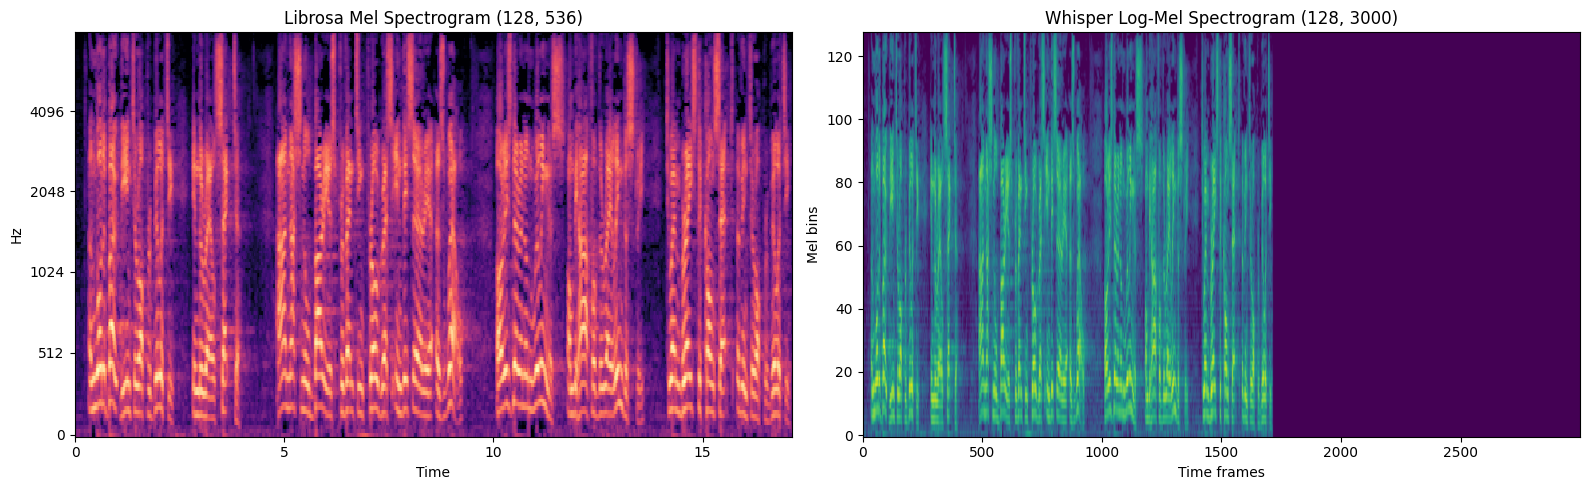

Whisper: 128 mel bins x 3000 frames (always padded to 30s)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Librosa mel spectrogram
mel_spec = librosa.feature.melspectrogram(y=audio_array, sr=sr, n_mels=128)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
librosa.display.specshow(mel_spec_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[0])
axes[0].set_title(f"Librosa Mel Spectrogram {mel_spec.shape}")

# Whisper log-mel spectrogram
whisper_mel = whisper_features.input_features[0].detach().cpu().numpy()
axes[1].imshow(whisper_mel, aspect="auto", origin="lower")
axes[1].set_title(f"Whisper Log-Mel Spectrogram {whisper_mel.shape}")
axes[1].set_xlabel("Time frames")
axes[1].set_ylabel("Mel bins")

plt.tight_layout()
plt.show()

print(f"Whisper: {whisper_mel.shape[0]} mel bins x {whisper_mel.shape[1]} frames (always padded to 30s)")

## Summary

**Key takeaways**:

1. **Dataset**: `speechbrain/LargeScaleASR` stores audio as raw bytes in `sample['wav']['bytes']`, decoded via `soundfile`
2. **Audio representation**: Raw waveform → mel spectrogram → Whisper encoder hidden states
3. **Whisper encoder output**: `[batch, 1500, 1280]` — 1500 time steps, each a 1280-dim vector
4. **Our task**: Project these 1280-dim vectors into Qwen2-VL's 3584-dim embedding space
5. **Token count**: Whisper pads to 30s → always 1500 tokens by default. We track actual audio lengths for dynamic handling.

**Next**: Notebook 02 — Tokenizer & Processor Modifications

In [13]:
# Clean up
del whisper_model, whisper_encoder, whisper_processor
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Memory cleaned.")

Memory cleaned.
